# Galactic Data Challange

## 1. Spectral fiting of Cyg-X1

1.1 The first step is to add the libraries.

In [1]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

import sys

import astropy.units as u

import numpy as np
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList, threeML_config
from astromodels import Parameter, Powerlaw

from pathlib import Path

%matplotlib inline

09:43:35 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=3924200;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=3924201;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=3924207;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=3924208;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=3924215;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=3924216;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

09:43:35 INFO      Starting 3ML!                                                                     ]8;id=3924223;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3924224;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=3924230;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3924231;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

09:43:36 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=3924266;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3924267;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=3924274;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=3924275;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=3924281;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3924282;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=3924287;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3924288;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=3924293;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3924294;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

1.2 Then we make a folder for data.


In [2]:
data_path = Path("../cosi_galactic_constrain_geo_data/data")
data_path.mkdir(parents=True, exist_ok=True)


1.3 We download and load the orientation file.

In [3]:
ori_path = data_path/"DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori"
fetch_wasabi_file("COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori", ori_path)


A file named ../cosi_galactic_constrain_geo_data/data/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori with the same ETag (ea0bf1fced99f3527579613debf4eaef-12) as the requested file already exists. Skipping.


In [4]:
ori_path = data_path/"DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori"
sc_orientation = SpacecraftHistory.open(ori_path)

1.4 We download the unbinned Cyg X1 data.

In [5]:
signal_path = data_path/"cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

In [6]:
fetch_wasabi_file("COSI-SMEX/DC3/Data/Sources/cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz", signal_path)

A file named ../cosi_galactic_constrain_geo_data/data/cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (fdd821a2cec15579976fcaed7b2c85bc-2) as the requested file already exists. Skipping.


1.5 We download the unbinned DC4 bakground.

In [7]:
background_path = data_path/"Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"

In [8]:
fetch_wasabi_file("COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz", background_path)


A file named ../cosi_galactic_constrain_geo_data/data/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz with the same ETag (1c67e7a1517ef1b6042696f925296e22-3046) as the requested file already exists. Skipping.


1.6 We download the response files.

In [9]:
img_response_path = data_path/"ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
fetch_wasabi_file("COSI-SMEX/DC4/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5", img_response_path)

A file named ../cosi_galactic_constrain_geo_data/data/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5 with the same ETag (a976a4c109df71db3333a464000d7241-5) as the requested file already exists. Skipping.


We look at the response.

In [10]:
from cosipy.response import FullDetectorResponse

img_response_path = data_path/"ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
with FullDetectorResponse.open(img_response_path) as response:

    print(repr(response))

dr = FullDetectorResponse.open(img_response_path)

FILENAME: '/Users/mabapple2025/Projects/NASA/COSI/cosi_galactic_constrain_geo_data/data/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 30
    EDGES: [0.0 deg, 6.0 deg, 12.0 deg, 18.0 deg, 24.0 d

1.7 We make the binned object from  cygX1 and bkg.

In [11]:
from cosipy import BinnedData

cygX1 = BinnedData("./cygX1.yaml")
cygX1.get_binned_data(unbinned_data=signal_path, output_name=data_path/"cygX1_binned_data")

bkg = BinnedData("./background.yaml")
bkg.get_binned_data(unbinned_data=background_path, output_name=data_path/"bkg_binned_data")


1.8 We project the binned data to 'Em', 'Phi', and 'PsiChi'.

In [12]:
from histpy import Histogram

cygX1_binned_signal = Histogram.open(data_path/"cygX1_binned_data.hdf5")
cygX1_binned_signal_projected = cygX1_binned_signal.project(['Em', 'Phi', 'PsiChi'])

bkg_binned_signal = Histogram.open(data_path/"bkg_binned_data.hdf5")
bkg_binned_signal_projected = bkg_binned_signal.project(['Em', 'Phi', 'PsiChi'])





1.9 We check the projected cygX1 and bkg for and zeros, nan, and inf values. The signal + bkg needed for Maximum likelihood analysis should be smooth. 

In [13]:
import numpy as np

def check_zeros(name, x):
    """
    Check an array/histogram contents for zeros, negative values, NaN, and inf.
    Works for numpy arrays and histpy-like Histogram objects.
    """

    # If this is a histpy Histogram, extract contents
    if hasattr(x, "todense") and hasattr(x.todense(), "contents"):
        arr = x.todense().contents
    elif hasattr(x, "contents"):
        arr = x.contents
    else:
        arr = x

    arr = np.asarray(arr, dtype=float)

    print(f"\n========== {name} ==========")
    print("shape       :", arr.shape)
    print("finite all  :", np.isfinite(arr).all())
    print("nan count   :", np.isnan(arr).sum())
    print("inf count   :", np.isinf(arr).sum())
    print("zero count  :", np.sum(arr == 0))
    print("negative    :", np.sum(arr < 0))
    print("<= 0 count  :", np.sum(arr <= 0))
    print("min         :", np.nanmin(arr))
    print("max         :", np.nanmax(arr))

    # Print locations of bad bins
    bad = (~np.isfinite(arr)) | (arr <= 0)

    print("bad bins    :", np.sum(bad))

    if np.any(bad):
        bad_idx = np.argwhere(bad)
        print("\nFirst bad-bin indices:")
        print(bad_idx[:20])

        print("\nFirst bad-bin values:")
        for idx in bad_idx[:20]:
            idx_tuple = tuple(idx)
            print(idx_tuple, arr[idx_tuple])

    return arr


# ============================================================
# Check observed total counts
# ============================================================

data_counts = check_zeros(
    "Observed data: source + background",
    cygX1_binned_signal_projected + bkg_binned_signal_projected
)


# ============================================================
# Check source-only injected counts
# ============================================================

src_counts = check_zeros(
    "Injected source counts",
    cygX1_binned_signal_projected
)


# ============================================================
# Check background template
# ============================================================

bkg_counts = check_zeros(
    "Background template",
    bkg_binned_signal_projected
)




========== Observed data: source + background ==========
shape       : (10, 30, 768)
finite all  : True
nan count   : 0
inf count   : 0
zero count  : 22296
negative    : 0
<= 0 count  : 22296
min         : 0.0
max         : 6101.0
bad bins    : 22296

First bad-bin indices:
[[ 0  0  0]
 [ 0  0  1]
 [ 0  0  2]
 [ 0  0  3]
 [ 0  0  4]
 [ 0  0  5]
 [ 0  0  6]
 [ 0  0  7]
 [ 0  0  8]
 [ 0  0  9]
 [ 0  0 10]
 [ 0  0 11]
 [ 0  0 12]
 [ 0  0 13]
 [ 0  0 14]
 [ 0  0 15]
 [ 0  0 16]
 [ 0  0 17]
 [ 0  0 18]
 [ 0  0 19]]

First bad-bin values:
(np.int64(0), np.int64(0), np.int64(0)) 0.0
(np.int64(0), np.int64(0), np.int64(1)) 0.0
(np.int64(0), np.int64(0), np.int64(2)) 0.0
(np.int64(0), np.int64(0), np.int64(3)) 0.0
(np.int64(0), np.int64(0), np.int64(4)) 0.0
(np.int64(0), np.int64(0), np.int64(5)) 0.0
(np.int64(0), np.int64(0), np.int64(6)) 0.0
(np.int64(0), np.int64(0), np.int64(7)) 0.0
(np.int64(0), np.int64(0), np.int64(8)) 0.0
(np.int64(0), np.int64(0), np.int64(9)) 0.0
(np.int64(0), np.int

1.10 Define a point source at the known location with a eqpair spectrum and add it to the model. This should be done beore preparing the 3ML components needed for analysis.

In [35]:
# Eqpair model
from astromodels.xspec.factory import *
from astromodels.xspec.xspec_settings import *


# ============================================================
# Load EQPAIR
# ============================================================
eqpair_spectrum = XS_eqpair()


# ============================================================
# EQPAIR setup for Cyg X-1 hard-state initial fit
# ============================================================


# ============================================================
# Stable EQPAIR setup for 3ML/COSI fitting
# Start with only the physically important continuum parameters free.
# ============================================================

# First freeze everything
for par in eqpair_spectrum.parameters.values():
    par.free = False


# ============================================================
# Main hard-to-soft compactness ratio.
# Controls the overall spectral hardness and is a useful fit parameter.
# ============================================================
eqpair_spectrum.l_hovl_s.value = 6.34
eqpair_spectrum.l_hovl_s.min_value = 2.0
eqpair_spectrum.l_hovl_s.max_value = 20.0
eqpair_spectrum.l_hovl_s.delta = 0.2
eqpair_spectrum.l_hovl_s.free = False

# ============================================================
# Seed-photon compactness.
# Often degenerate with l_hovl_s and normalization, so keep it fixed initially.
# ============================================================
eqpair_spectrum.l_bb.value = 1.0
eqpair_spectrum.l_bb.min_value = -15.0
eqpair_spectrum.l_bb.max_value = 35.0
eqpair_spectrum.l_bb.delta = 1.0
eqpair_spectrum.l_bb.free = False

# ============================================================
# Seed blackbody temperature.
# In this XSPEC EQPAIR implementation the value is specified in eV.
# ============================================================
eqpair_spectrum.kt_bb.value = 200.0
eqpair_spectrum.kt_bb.min_value = 50.0
eqpair_spectrum.kt_bb.max_value = 500.0
eqpair_spectrum.kt_bb.delta = 5.0
eqpair_spectrum.kt_bb.free = False

# ============================================================
# Fraction of hard compactness injected into nonthermal electrons.
# Important for the MeV tail; keep fixed until the basic continuum fit converges.
# ============================================================
eqpair_spectrum.l_ntol_h.value = 0.9
eqpair_spectrum.l_ntol_h.min_value = 0.0
eqpair_spectrum.l_ntol_h.max_value = 1.8
eqpair_spectrum.l_ntol_h.delta = 0.05
eqpair_spectrum.l_ntol_h.free = False

# ============================================================
# Thomson optical depth of background electrons.
# Controls spectral curvature and the cutoff; fit together with norm and l_hovl_s.
# ============================================================
eqpair_spectrum.tau_p.value = 1.29
eqpair_spectrum.tau_p.min_value = 0.3
eqpair_spectrum.tau_p.max_value = 4.0
eqpair_spectrum.tau_p.delta = 0.1
eqpair_spectrum.tau_p.free = False

# ============================================================
# Radius of the emitting region in cm.
# Usually weakly constrained by a COSI-only spectrum, so keep fixed initially.
# ============================================================
eqpair_spectrum.radius.value = 1.0e7
eqpair_spectrum.radius.min_value = 1.0e7
eqpair_spectrum.radius.max_value = 1.0e7
eqpair_spectrum.radius.delta = 1.0e5
eqpair_spectrum.radius.free = False

# ============================================================
# Minimum Lorentz factor of the injected nonthermal electron distribution.
# Keep fixed during the initial fit.
# ============================================================
eqpair_spectrum.g_min.value = 1.3
eqpair_spectrum.g_min.min_value = 1.2
eqpair_spectrum.g_min.max_value = 10.0
eqpair_spectrum.g_min.delta = 0.01
eqpair_spectrum.g_min.free = False

# ============================================================
# Maximum Lorentz factor of the injected nonthermal electron distribution.
# Keep fixed initially and free only if the high-energy tail requires adjustment.
# ============================================================
eqpair_spectrum.g_max.value = 1000.0
eqpair_spectrum.g_max.min_value = 100.0
eqpair_spectrum.g_max.max_value = 10000.0
eqpair_spectrum.g_max.delta = 100.0
eqpair_spectrum.g_max.free = False

# ============================================================
# Power-law index of the injected nonthermal electron distribution.
# Keep fixed until the continuum fit is stable.
# ============================================================
eqpair_spectrum.g_inj.value = 2.9
eqpair_spectrum.g_inj.min_value = 1.0
eqpair_spectrum.g_inj.max_value = 5.0
eqpair_spectrum.g_inj.delta = 0.1
eqpair_spectrum.g_inj.free = False

# ============================================================
# Pair-injection control parameter.
# Set to zero when no additional pair injection is included.
# ============================================================
eqpair_spectrum.pairinj.value = 0.0
eqpair_spectrum.pairinj.min_value = 0.0
eqpair_spectrum.pairinj.max_value = 0.0
eqpair_spectrum.pairinj.delta = 0.1
eqpair_spectrum.pairinj.free = False

# ============================================================
# Cosine of the inclination angle used by the reflection component.
# Keep fixed initially because it is usually weakly constrained by COSI-only data.
# ============================================================
eqpair_spectrum.cosincl.value = 0.891
eqpair_spectrum.cosincl.min_value = 0.05
eqpair_spectrum.cosincl.max_value = 0.95
eqpair_spectrum.cosincl.delta = 0.05
eqpair_spectrum.cosincl.free = False

# ============================================================
# Reflection scaling factor.
# Keep fixed initially and free only after the continuum parameters converge.
# ============================================================
eqpair_spectrum.refl.value = 0.25
eqpair_spectrum.refl.min_value = 0.0
eqpair_spectrum.refl.max_value = 1.0
eqpair_spectrum.refl.delta = 0.1
eqpair_spectrum.refl.free = False

# ============================================================
# Iron abundance relative to the reference abundance.
# Keep fixed initially unless reflection features provide useful constraints.
# ============================================================
eqpair_spectrum.fe_abund.value = 1.0
eqpair_spectrum.fe_abund.min_value = 0.1
eqpair_spectrum.fe_abund.max_value = 10.0
eqpair_spectrum.fe_abund.delta = 0.1
eqpair_spectrum.fe_abund.free = False

# ============================================================
# Overall metal abundance relative to the reference abundance.
# Keep fixed initially unless reflection features provide useful constraints.
# ============================================================
eqpair_spectrum.ab_met.value = 1.0
eqpair_spectrum.ab_met.min_value = 0.1
eqpair_spectrum.ab_met.max_value = 10.0
eqpair_spectrum.ab_met.delta = 0.1
eqpair_spectrum.ab_met.free = False

# ============================================================
# Disk temperature parameter used by the reflection treatment.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.t_disk.value = 1.0e6
eqpair_spectrum.t_disk.min_value = 1.0e6
eqpair_spectrum.t_disk.max_value = 1.0e6
eqpair_spectrum.t_disk.delta = 10.0
eqpair_spectrum.t_disk.free = False

# ============================================================
# Ionization parameter of the reflector.
# A value of zero corresponds to a neutral reflector.
# ============================================================
eqpair_spectrum.xi.value = 0.0
eqpair_spectrum.xi.min_value = 0.0
eqpair_spectrum.xi.max_value = 0.0
eqpair_spectrum.xi.delta = 10.0
eqpair_spectrum.xi.free = False

# ============================================================
# Radial emissivity index of the reflection component.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.beta.value = -10.0
eqpair_spectrum.beta.min_value = -10.0
eqpair_spectrum.beta.max_value = -10.0
eqpair_spectrum.beta.delta = 0.1
eqpair_spectrum.beta.free = False

# ============================================================
# Inner disk radius used by the reflection model.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.rin.value = 10.0
eqpair_spectrum.rin.min_value = 10.0
eqpair_spectrum.rin.max_value = 10.0
eqpair_spectrum.rin.delta = 0.1
eqpair_spectrum.rin.free = False

# ============================================================
# Outer disk radius used by the reflection model.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.rout.value = 1000.0
eqpair_spectrum.rout.min_value = 1000.0
eqpair_spectrum.rout.max_value = 1000.0
eqpair_spectrum.rout.delta = 1.0
eqpair_spectrum.rout.free = False

# ============================================================
# Source redshift.
# For the Galactic source Cyg X-1, keep this fixed at zero.
# ============================================================
eqpair_spectrum.redshift.value = 0.0
eqpair_spectrum.redshift.min_value = 0.0
eqpair_spectrum.redshift.max_value = 0.0
eqpair_spectrum.redshift.delta = 0.01
eqpair_spectrum.redshift.free = False

# ============================================================
# Overall EQPAIR normalization.
# Fit this parameter with a bounded range to avoid unstable likelihood evaluations.
# ============================================================
eqpair_spectrum.norm.value = 5.2e-8
eqpair_spectrum.norm.min_value = 1.0e-10
eqpair_spectrum.norm.max_value = 1.0e-6
eqpair_spectrum.norm.delta = 1.0e-9
eqpair_spectrum.norm.free = False

# ============================================================
# Display the spectrum parameters and setup before fitting.
# ============================================================
eqpair_spectrum.display()

# ============================================================
# Define source and model
# ============================================================
cygX1_model = PointSource(
    "cygX1",
    l=71.334,
    b=3.066,
    spectral_shape=eqpair_spectrum,
)

model = Model(cygX1_model)
model.display()

* description: The eqpair model from XSpec (https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
  * formula: $n.a.$
  * parameters:
    * l_hovl_s:
      * value: 6.34
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 2.0
      * max_value: 20.0
      * unit: ''
      * is_normalization: false
      * delta: 0.2
      * free: false
    * l_bb:
      * value: 1.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: -15.0
      * max_value: 35.0
      * unit: ''
      * is_normalization: false
      * delta: 1.0
      * free: false
    * kt_bb:
      * value: 200.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 50.0
      * max_value: 500.0
      * unit: eV
      * is_normalization: false
      * delta: 5.0
      * free: false
    * l_ntol_h:
      * value: 0.9
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.0
      * max_value: 1.8
      * unit: ''
      * is_normalization: false
      * delta: 0.05
      * free: false
    * tau_p:
      * value: 1.29
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.3
      * max_value: 4.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * radius:
      * value: 10000000.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 10000000.0
      * max_value: 10000000.0
      * unit: cm
      * is_normalization: false
      * delta: 100000.0
      * free: false
    * g_min:
      * value: 1.3
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 1.2
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.01
      * free: false
    * g_max:
      * value: 1000.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 100.0
      * max_value: 10000.0
      * unit: ''
      * is_normalization: false
      * delta: 100.0
      * free: false
    * g_inj:
      * value: 2.9
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 1.0
      * max_value: 5.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * pairinj:
      * value: 0.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.0
      * max_value: 0.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * cosincl:
      * value: 0.891
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.05
      * max_value: 0.95
      * unit: ''
      * is_normalization: false
      * delta: 0.05
      * free: false
    * refl:
      * value: 0.25
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.0
      * max_value: 1.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * fe_abund:
      * value: 1.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.1
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * ab_met:
      * value: 1.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.1
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * t_disk:
      * value: 1000000.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 1000000.0
      * max_value: 1000000.0
      * unit: K
      * is_normalization: false
      

,N
Point sources,1
Extended sources,0
Particle sources,0


1.11 We plot the initial spectrum.

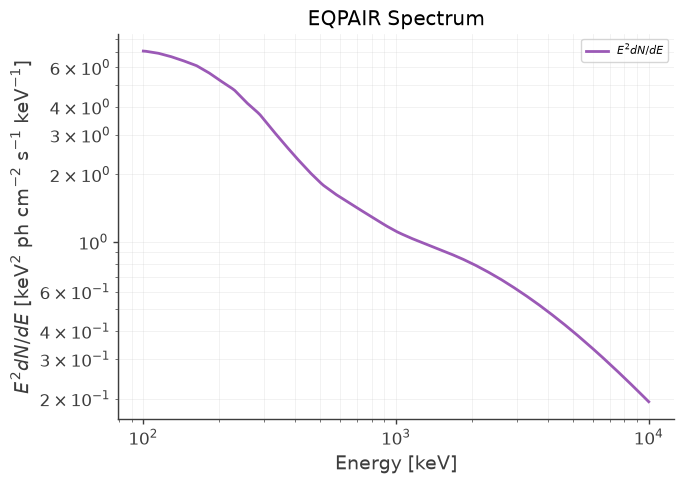

In [36]:
# ============================================================
# Energy grid in keV
# ============================================================
energies = np.logspace(np.log10(100), np.log10(10000), 200)

# ============================================================
# Evaluate EQPAIR: dN/dE
# ============================================================
dnde = eqpair_spectrum(energies)

# Convert Quantity to plain numpy array if needed
try:
    dnde = dnde.value
except AttributeError:
    pass

# ============================================================
# Compute E^2 dN/dE
# ============================================================
e2dnde = energies**2 * dnde

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(
    energies,
    e2dnde,
    lw=2,
    label=r"$E^2 dN/dE$"
)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$E^2 dN/dE$ [keV$^2$ ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
ax.set_title("EQPAIR Spectrum")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

1.12 We prepare all the components necessary for maximum likelihood analysis with 3ML.

In [37]:
# We smoothe the background template by adding a small value to avoid issues with zero counts 
# in the likelihood evaluation.
eps = 1e-12
bkg_binned_signal_projected += eps



# Wrap the raw BinnedData objects into the appropiate data interface.
data = EmCDSBinnedData(cygX1_binned_signal_projected + bkg_binned_signal_projected)  # total counts (source + background)


# Use the background model to initialize a background expectation interface.
# For this particular background interface implementation, only the normalization values are free.
bkg_dist = {"total_bkg":bkg_binned_signal_projected}
Free_Norm_bkg = FreeNormBinnedBackground(bkg_dist, 
                               sc_history=sc_orientation, 
                               copy = True)


# Wrape the raw response with BinnedInstrumentResponseInterface implementation
instrument_response = BinnedInstrumentResponse(dr, data)

# Initialize the 3ML Point Source response

# Note: Currently we're using the same NuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
psr = BinnedThreeMLPointSourceResponse(data = data,
                                       instrument_response = instrument_response,
                                       sc_history=sc_orientation,
                                       energy_axis = dr.axes['Ei'],
                                       polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                       nside = 2*data.axes['PsiChi'].nside)

# Pass the 3ML Point Source response to interface implementation that will peform the 
# folding with the spectrum
response = BinnedThreeMLModelFolding(data = data, 
                                     point_source_response = psr)

# Likelihood to use
like_fun = PoissonLikelihood(data, response, Free_Norm_bkg)

# Init 3ML plugin
cosi = ThreeMLPluginInterface('cosi',
                              like_fun,
                              response,
                              Free_Norm_bkg)

# Init background parameters, consider as "nuisance parameters"
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,  # background parameter
                                      1.0,  # initial value of parameter
                                      min_value=0,  # minimum value of parameter
                                      max_value= 100,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      unit = u.Hz
                                      )

1.13 Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit.

In [39]:
# keep the background free or freeze it
cosi.nuisance_parameters["cosi_total_bkg"].free = True
print(cosi.nuisance_parameters)

# Add the plugin to a 3ML JointLikelihood
plugins = DataList(cosi)

# Define the JointLikelihood and print the free parameters to verify the setup
like = JointLikelihood(model, plugins, verbose=False)
print(like._free_parameters)


{'cosi_total_bkg': Parameter total_bkg = 1.0 [Hz]
(min_value = 0.0, max_value = 100.0, delta = 0.05, free = True)}


10:15:44 INFO      set the minimizer to minuit                                             ]8;id=3924620;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=3924621;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

OrderedDict({'total_bkg': Parameter total_bkg = 1.0 [Hz]
(min_value = 0.0, max_value = 100.0, delta = 0.05, free = True)})


1.14 Run the maximum likelihood analysis.

In [40]:
import warnings
import traceback
from scipy.integrate import IntegrationWarning

warnings.simplefilter("error", IntegrationWarning)

try:
    like.fit()
except IntegrationWarning:
    print("IntegrationWarning traceback:")
    traceback.print_exc()
except Exception as e:
    print("Other error:")
    traceback.print_exc()

10:15:57 WARNING   The current value of the parameter l_hovl_s (1.0) was below the new minimum     ]8;id=3924626;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=3924627;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  2.0.                                                                                             

         WARNING   The current value of the parameter l_bb (100.0) was above the new maximum 35.0. ]8;id=3924632;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=3924633;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter tau_p (0.1) was below the new minimum 0.3.   ]8;id=3924638;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=3924639;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter norm (1.0) was above the new maximum 1e-06.  ]8;id=3924644;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=3924645;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Best fit values:

...

1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1087365923.4930277
total,-1087365923.4930277


Values of statistical measures:

,statistical measures
AIC,-2174731844.986038
BIC,-2174731834.638483


1.15 We get the result of the analysis

In [41]:
results = like.results

1.16 We generate the real spectrum form spectrum file passed to MEGAlib.

In [42]:
import numpy as np
import astropy.units as u

def read_dat_spectrum(filename):
    energy = []
    flux = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("DP"):
                parts = line.split()
                energy.append(float(parts[1]))
                flux.append(float(parts[2]))

    energy = np.array(energy) * u.keV
    flux = np.array(flux) / (u.cm**2 * u.s * u.keV)

    return energy, flux


energy, flux = read_dat_spectrum("./cygX1_hard_0.1-10_spec.dat")

print(energy[:5])
print(flux[:5])

import numpy as np
import astropy.units as u
from astromodels import Function1D, FunctionMeta


class TabulatedSpectrum(Function1D, metaclass=FunctionMeta):
    r"""
    description :
        Interpolated photon spectrum from a DAT file.

    latex : $ F(E) $

    parameters :
        K :
            desc : Overall normalization
            initial value : 1.0
            min : 0.0
            max : 1e10
            delta : 0.1
            free : False
    """

    def _set_units(self, x_unit, y_unit):
        self.K.unit = y_unit

    def set_table(self, energy, flux):
        self.energy = energy.to(u.keV).value
        self.flux = flux.to(1 / (u.cm**2 * u.s * u.keV)).value

    def evaluate(self, x, K):
        x = np.asarray(x)

        return K * np.interp(
            x,
            self.energy,
            self.flux,
            left=0.0,
            right=0.0
        )
    

eqpair_spectrum_num = TabulatedSpectrum()
eqpair_spectrum_num.set_table(energy, flux)

eqpair_spectrum_num.K.value = 1.0
eqpair_spectrum_num.K.free = False

[100.    109.854 120.679 132.571 145.635] keV
[0.00070882 0.00057886 0.00046873 0.00037669 0.00030117] 1 / (keV s cm2)


1.17 Plot the fitted and injected spectra.

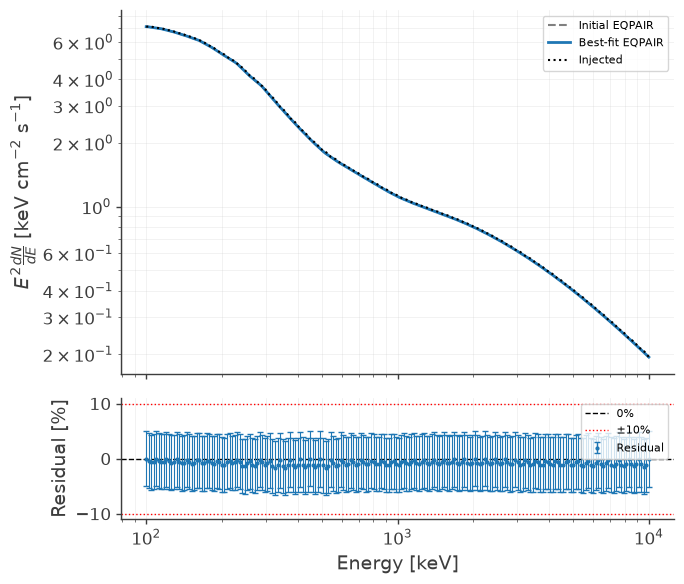

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Energy grid in keV
# ============================================================
energies = np.logspace(np.log10(100), np.log10(10000), 200)

# ============================================================
# Injected EQPAIR spectrum
# ============================================================
flux_inj = np.array([
    eqpair_spectrum_num.evaluate_at(e)
    for e in energies
])

# ============================================================
# Binned energy information
# ============================================================
binned_energy_edges = cygX1.binned_data.axes["Em"].edges.value

binned_energy = 0.5 * (
    binned_energy_edges[:-1] + binned_energy_edges[1:]
)

bin_sizes = (
    binned_energy_edges[1:] - binned_energy_edges[:-1]
)

# ============================================================
# Initial EQPAIR spectrum
# Assumes e2dnde already exists from your initial model.
# If it does not, replace this section with your initial model.
# ============================================================
initial_e2 = e2dnde

# ============================================================
# Best-fit EQPAIR spectrum
# ============================================================
flux_best_fit = np.array([
    eqpair_spectrum(e)
    for e in energies
])

# ============================================================
# Convert to E^2 dN/dE
# ============================================================
best_fit_e2 = energies**2 * flux_best_fit
inj_e2 = energies**2 * flux_inj

# ============================================================
# Best-fit spectrum uncertainty
#
# IMPORTANT:
# Replace this temporary fractional uncertainty with your real
# best-fit spectral uncertainty from the fit/posterior.
# ============================================================
fractional_best_fit_error = 0.05   # temporary 5% uncertainty

best_fit_e2_err = fractional_best_fit_error * best_fit_e2

# ============================================================
# Percent residual
# Residual [%] = 100 * (Best-fit - Injected) / Injected
# ============================================================
residual_percent = np.full_like(energies, np.nan, dtype=float)
residual_percent_err = np.full_like(energies, np.nan, dtype=float)

valid = (
    np.isfinite(best_fit_e2)
    & np.isfinite(inj_e2)
    & np.isfinite(best_fit_e2_err)
    & (inj_e2 > 0)
)

residual_percent[valid] = (
    100.0
    * (best_fit_e2[valid] - inj_e2[valid])
    / inj_e2[valid]
)

# Assuming injected spectrum is exact:
# sigma_residual = 100 * sigma_best_fit / injected
residual_percent_err[valid] = (
    100.0
    * best_fit_e2_err[valid]
    / inj_e2[valid]
)

# ============================================================
# Plot spectrum + residual
# ============================================================
fig, (ax, ax_res) = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# ============================================================
# Top panel: spectra
# ============================================================
ax.plot(
    energies,
    initial_e2,
    color="gray",
    ls="--",
    lw=1.5,
    label="Initial EQPAIR"
)

ax.plot(
    energies,
    best_fit_e2,
    color="tab:blue",
    lw=2,
    label="Best-fit EQPAIR"
)

ax.plot(
    energies,
    inj_e2,
    color="black",
    ls=":",
    lw=1.5,
    label="Injected"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(
    r"$E^2 \frac{dN}{dE}$ "
    r"[keV cm$^{-2}$ s$^{-1}$]"
)

ax.grid(True, which="both", alpha=0.3)
ax.legend()

# ============================================================
# Bottom panel: percent residual with error bars
# ============================================================
ax_res.axhline(
    0,
    color="black",
    lw=1,
    ls="--",
    label="0%"
)

ax_res.axhline(
    10,
    color="red",
    lw=1,
    ls=":",
    label=r"$\pm 10\%$"
)

ax_res.axhline(
    -10,
    color="red",
    lw=1,
    ls=":"
)

ax_res.errorbar(
    energies,
    residual_percent,
    yerr=residual_percent_err,
    fmt="o",
    linestyle="none",
    color="tab:blue",
    markersize=2,
    capsize=2,
    elinewidth=0.8,
    label="Residual"
)

ax_res.set_xscale("log")

ax_res.set_xlabel("Energy [keV]")
ax_res.set_ylabel("Residual [%]")

ax_res.grid(True, which="both", alpha=0.3)
ax_res.legend(loc="best")

plt.tight_layout()
plt.show()

1.18 Plot the fitted spectrum convolved with the response, as well as the simulated source counts

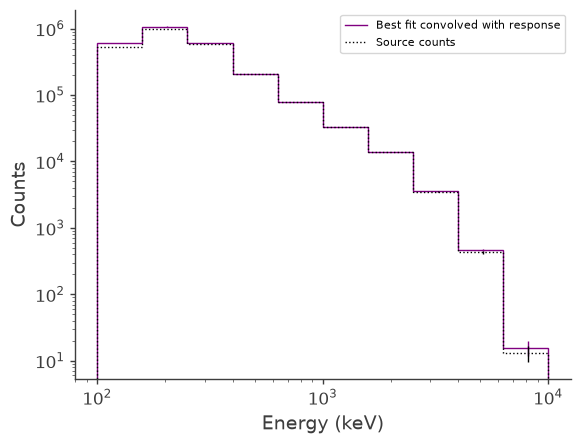

In [52]:
expectation = response.expectation()

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(cygX1.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, cygX1.binned_data.project('Em').todense().contents, yerr=np.sqrt(cygX1.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

_ = ax.legend()

1.19 Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source + background counts.

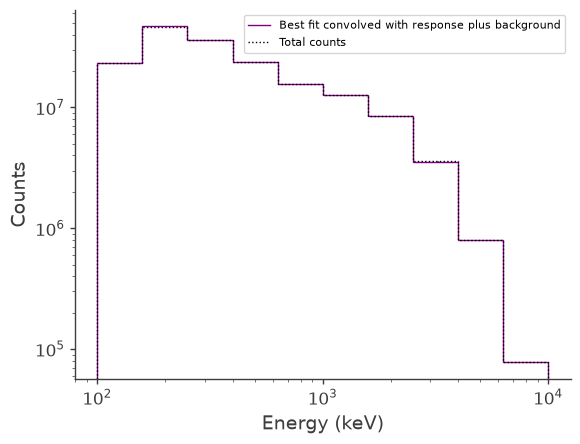

In [53]:
expectation_bkg = Free_Norm_bkg.expectation(copy = True)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()